## Explore FEMA table service
This notebook explores how the ArcGIS API for Python can access and analyzed web services

In [1]:
#Packages
import pandas as pd
from arcgis.gis import GIS
from arcgis.features import GeoAccessor, FeatureLayerCollection

In [2]:
#Login to GIS
gis = GIS("home")

In [3]:
#Search for the table service
items = gis.content.search('title:"FEMA_FloodClaims" AND owner:jpfay_dukeuniv',item_type='Feature Service')
items


[<Item title:"FEMA_FloodClaims" type:Table Layer owner:jpfay_dukeuniv>]

In [4]:
#Get the first [and only item]
the_item = items[0]
the_item

<Item title:"FEMA_FloodClaims" type:Table Layer owner:jpfay_dukeuniv>

In [5]:
#Get the table object from the table service
the_table = the_item.tables[0]
the_table

<Table url:"https://services1.arcgis.com/XBhYkoXKJCRHbe7M/arcgis/rest/services/FEMA Flood Claims2/FeatureServer/0">

* Info on Table objects: https://developers.arcgis.com/python/latest/api-reference/arcgis.features.toc.html#table

In [6]:
#Subset records for Durham Co and convert to a dataframe
df_Durham = the_table.query("countyCode = '37063'").sdf
df_Durham.head()


,index_,dateOfLoss,occupancyType,amountPaidOnBuildingClaim,totalBuildingInsuranceCoverage,yearOfLoss,buildingDamageAmount,netBuildingPaymentAmount,causeOfDamage,floodEvent,state,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,ObjectId
0,<NA>,1999-09-16,1,379.42,133000,1999,880.0,379.42,2,Hurricane Floyd,NC,27701,37063,37063000302,370630003022,36.0,-78.9,208
1,<NA>,2012-08-26,1,<NA>,150000,2012,<NA>,0.0,0,<NA>,NC,27707,37063,37063002018,370630020182,35.9,-79.0,261
2,<NA>,2024-09-27,11,25612.03,250000,2024,26862.0,25612.03,2,Hurricane Helene,NC,27705,37063,37063001705,370630017054,36.0,-78.9,658
3,<NA>,2018-09-17,11,5171.83,61000,2018,7171.0,5171.83,2,Hurricane Florence,NC,27712,37063,37063001601,370630016014,36.1,-78.9,693
4,<NA>,1996-09-05,1,1033.7,194700,1996,1534.0,1033.7,2,Hurricane Fran,NC,27704,37063,37063001708,370630017081,36.1,-78.9,1179


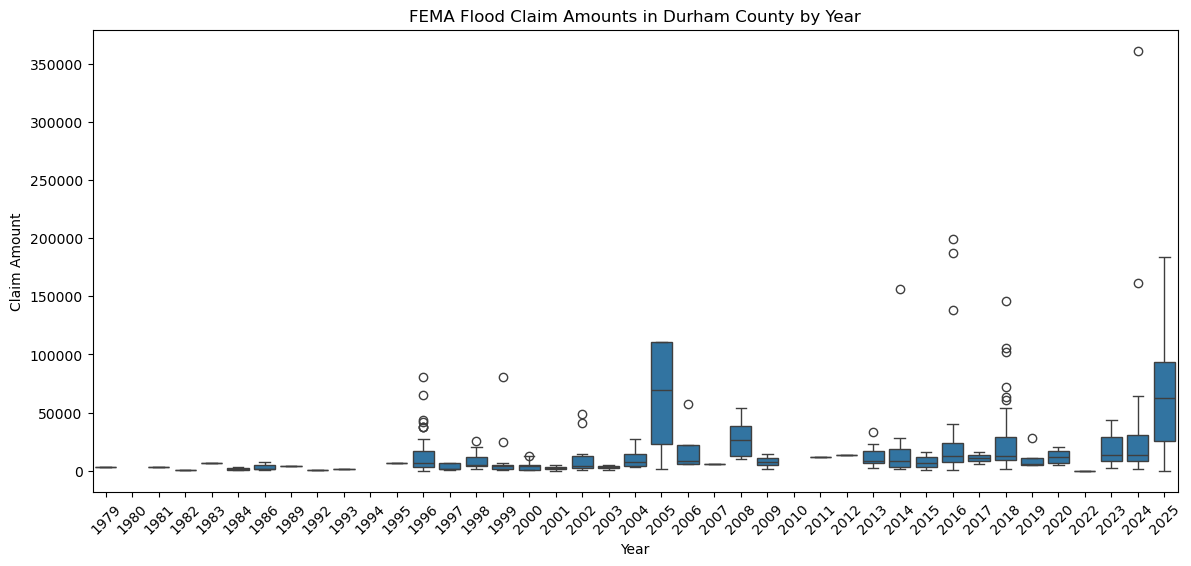

In [7]:
#Create a box plot of the flood claim amounts in Durham Co by year
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,6))
sns.boxplot(data=df_Durham, x='yearOfLoss', y='buildingDamageAmount')
plt.title('FEMA Flood Claim Amounts in Durham County by Year')
plt.xlabel('Year')
plt.ylabel('Claim Amount')
plt.xticks(rotation=45)
plt.show()

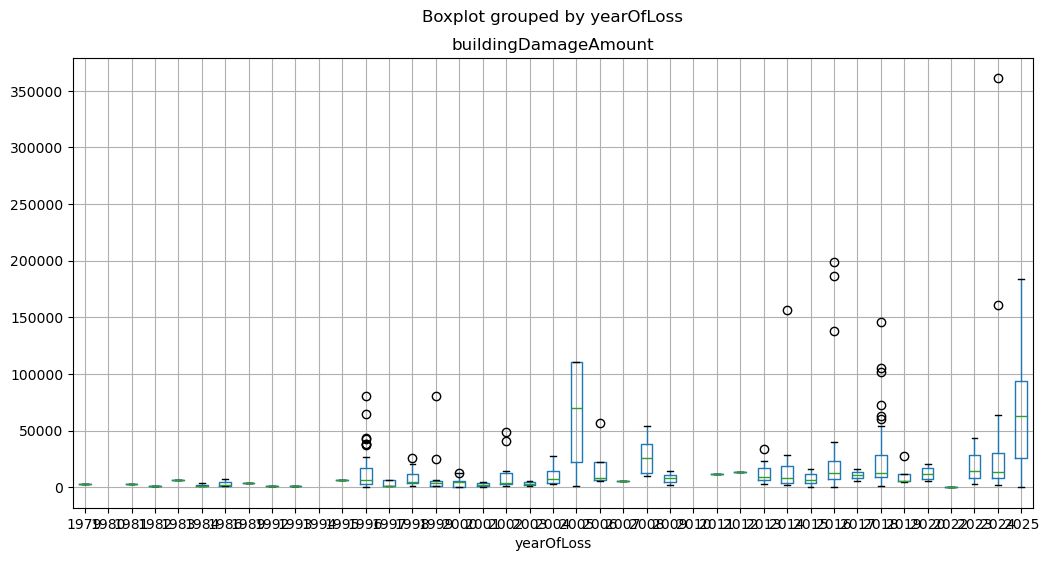

In [8]:
#Create a simple box plot
df_Durham.boxplot(column='buildingDamageAmount',by='yearOfLoss',figsize=(12,6));